In [9]:
import os, sys

os.chdir(os.path.expanduser("~/QIAO0042/models/acv/facemask/"))
sys.path.insert(0, os.getcwd())
print("CWD:", os.getcwd())

CWD: /scratch-share/QIAO0042/models/acv/facemask


In [10]:
import os
import time
import torch
from torch.utils.data import DataLoader
import wandb

from unet import UNet
from losses import CEDiceLoss
from metrics import confusion_matrix, f1_macro_from_cm
from palette import NUM_CLASSES
from dataset import FaceParsingDataset
from split_utils import list_images, make_split, save_split

In [11]:
import torch
from unet import UNet

model = UNet(num_classes=19, base=23)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)  # ~1,732,172  (budget: 1,821,085)

x = torch.randn(2, 3, 512, 512)
y = model(x)
print("Output shape:", y.shape)  # (2, 19, 512, 512)

Trainable params: 1732172
Output shape: torch.Size([2, 19, 512, 512])


In [12]:
from augment import flip_with_label_swap

# Correct horizontal flip for face parsing:
# - flips image and mask spatially (p=0.5)
# - then swaps laterally-paired labels so semantics stay consistent:
#     l_eye(4) ↔ r_eye(5),  l_brow(6) ↔ r_brow(7),  l_ear(8) ↔ r_ear(9)
# Without the swap the model sees contradictory priors
# (l_eye sometimes on left, sometimes on right of the image).

def aug_fn(img, mask):
    return flip_with_label_swap(img, mask, p=0.5)

In [13]:
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from palette import rgb_to_label

# --- data paths ---
img_dir  = "train/images"
mask_dir = "train/masks"

# --- split config ---
seed      = 42
val_ratio = 0.1            # 900 train / 100 val

# --- train config ---
batch_size    = 4
lr            = 1e-2
warmup_epochs = 5
epochs        = 300        # was 100 — more budget for the schedule to work through
base_width    = 23
dice_w        = 0.7
ckpt_path     = "checkpoints/split_best.pt"
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- split ---
all_files = list_images(img_dir)
train_files, val_files = make_split(all_files, val_ratio=val_ratio, seed=seed)
save_split(train_files, val_files, out_dir="splits", tag=f"seed{seed}_vr{val_ratio}")
print(f"Split: {len(train_files)} train / {len(val_files)} val")

# -----------------------------------------------------------------------
# Class weights via median-frequency balancing (train split only)
# -----------------------------------------------------------------------
print("Computing class pixel frequencies from training masks ...")
pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
mask_lookup  = {
    p.stem: p for p in Path(mask_dir).iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg"}
}
for fn in train_files:
    stem     = Path(fn).stem
    mask_rgb = np.array(PILImage.open(mask_lookup[stem]).convert("RGB"), dtype=np.uint8)
    labels   = rgb_to_label(mask_rgb)
    for c in range(NUM_CLASSES):
        pixel_counts[c] += int((labels == c).sum())

freq             = pixel_counts / pixel_counts.sum()
median_freq      = float(np.median(freq[freq > 0]))
class_weights_np = np.where(freq > 0, median_freq / freq, 1.0)
class_weights    = torch.tensor(class_weights_np, dtype=torch.float32)

print(f"{'cls':>4}  {'freq':>8}  {'weight':>8}")
for i, (f, w) in enumerate(zip(freq, class_weights_np)):
    print(f"  {i:2d}   {f:.5f}   {w:.3f}")

# --- datasets ---
train_ds = FaceParsingDataset(img_dir, mask_dir, file_list=train_files, augment=aug_fn)
val_ds   = FaceParsingDataset(img_dir, mask_dir, file_list=val_files,   augment=None)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2,          shuffle=False, num_workers=2, pin_memory=True)

# --- model ---
model      = UNet(num_classes=NUM_CLASSES, base=base_width).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- optimizer (lower weight decay reduces regularisation pressure) ---
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)  # was 1e-4

# --- scheduler: linear warmup -> cosine warm restarts ---
# Restarts at epoch 5+50=55, 5+50+100=155, 5+50+100+200=355 (> 300, so only 2 full restarts).
# Each restart lets the model escape the current basin and continue lowering loss.
scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-6   # was CosineAnnealingLR with eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_warmup, scheduler_cosine],
    milestones=[warmup_epochs],
)

# --- loss: class-weighted CE + Dice ---
criterion = CEDiceLoss(
    num_classes=NUM_CLASSES,
    dice_weight=dice_w,
    class_weights=class_weights.to(device),
)

# --- AMP scaler (new non-deprecated API) ---
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

print(f"\nModel    : UNet(base={base_width})  |  Params: {num_params:,}")
print(f"Device   : {device}  |  Epochs: {epochs}  (warmup={warmup_epochs})")
print(f"Schedule : warmup({warmup_epochs}) → CosineWarmRestarts(T_0=50, T_mult=2, eta_min=1e-6)")
print(f"Restarts : ~epoch 55, ~epoch 155  (within 300 epoch budget)")

# --- wandb ---
wandb.init(
    project="face-parsing-unet",
    name=f"unet_base{base_width}_split_classW_hflip_cawr_e300",
    config={
        "model":          "UNet",
        "num_classes":    NUM_CLASSES,
        "base_width":     base_width,
        "params":         num_params,
        "loss":           "CE(class_weights) + Dice",
        "dice_weight":    dice_w,
        "lr":             lr,
        "warmup_epochs":  warmup_epochs,
        "batch_size":     batch_size,
        "epochs":         epochs,
        "seed":           seed,
        "val_ratio":      val_ratio,
        "train_samples":  len(train_files),
        "val_samples":    len(val_files),
        "augmentation":   "HFlip+LabelSwap (l/r eye,brow,ear)",
        "scheduler":      "warmup+CosineAnnealingWarmRestarts(T0=50,Tmult=2)",
        "eta_min":        1e-6,
        "weight_decay":   1e-5,
        "amp":            True,
        "grad_clip":      1.0,
    },
)

Split: 900 train / 100 val
Computing class pixel frequencies from training masks ...
 cls      freq    weight
   0   0.28949   0.015
   1   0.25260   0.017
   2   0.02066   0.204
   3   0.00283   1.489
   4   0.00223   1.888
   5   0.00221   1.903
   6   0.00421   1.000
   7   0.00410   1.027
   8   0.00476   0.885
   9   0.00387   1.087
  10   0.00321   1.310
  11   0.00420   1.002
  12   0.00683   0.616
  13   0.31476   0.013
  14   0.00688   0.612
  15   0.00251   1.678
  16   0.00018   23.034
  17   0.04010   0.105
  18   0.03437   0.122
Loaded 900 samples from train/images
Loaded 100 samples from train/images

Model    : UNet(base=23)  |  Params: 1,732,172
Device   : cuda  |  Epochs: 300  (warmup=5)
Schedule : warmup(5) → CosineWarmRestarts(T_0=50, T_mult=2, eta_min=1e-6)
Restarts : ~epoch 55, ~epoch 155  (within 300 epoch budget)


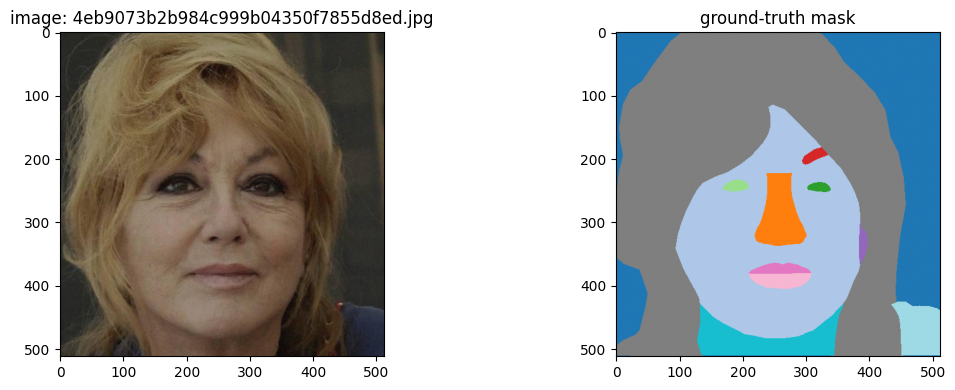

In [14]:
import matplotlib.pyplot as plt

img, mask, fname = train_ds[8]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img.permute(1, 2, 0))
axes[0].set_title(f"image: {fname}")
axes[1].imshow(mask, cmap="tab20")
axes[1].set_title("ground-truth mask")
plt.tight_layout()
plt.show()

In [15]:
@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)

    for imgs, masks, _ in loader:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
            logits = model(imgs)

        pred = logits.argmax(dim=1)
        cm   = confusion_matrix(pred.cpu(), masks.cpu(), num_classes=NUM_CLASSES)
        cm_total += cm

    macro_f1, per_class_f1 = f1_macro_from_cm(cm_total)
    return macro_f1, per_class_f1


def train():
    print(f"Trainable params: {num_params:,}")
    best_f1 = -1.0
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    for epoch in range(1, epochs + 1):
        model.train()
        t0      = time.time()
        running = 0.0

        for imgs, masks, _ in train_loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                logits = model(imgs)
                loss   = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running += loss.item()

        train_loss = running / max(1, len(train_loader))
        scheduler.step()
        val_f1, per_class_f1 = validate(model, val_loader, device)
        elapsed = time.time() - t0

        wandb.log({
            "epoch":          epoch,
            "train/loss":     train_loss,
            "val/macro_f1":   val_f1,
            "time/epoch_sec": elapsed,
            "lr":             scheduler.get_last_lr()[0],
        })

        print(f"[{epoch:03d}/{epochs}] loss={train_loss:.4f}  "
              f"val_F1={val_f1:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  time={elapsed:.1f}s")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({
                "model":          model.state_dict(),
                "optimizer":      optimizer.state_dict(),
                "epoch":          epoch,
                "best_f1":        best_f1,
                "per_class_f1":   per_class_f1.tolist(),
                "config":         dict(wandb.config),
            }, ckpt_path)
            print(f"  saved {ckpt_path}  (F1={best_f1:.4f})")

    print(f"\nBest val macro-F1: {best_f1:.4f}")
    wandb.finish()

In [ ]:
train()

Trainable params: 1,732,172


[001/300] loss=2.6185  val_F1=0.2100  lr=2.80e-03  time=8.8s
  saved checkpoints/split_best.pt  (F1=0.2100)
[002/300] loss=1.9328  val_F1=0.2945  lr=4.60e-03  time=8.9s
  saved checkpoints/split_best.pt  (F1=0.2945)
[003/300] loss=1.6802  val_F1=0.3234  lr=6.40e-03  time=8.9s
  saved checkpoints/split_best.pt  (F1=0.3234)
[004/300] loss=1.4843  val_F1=0.4402  lr=8.20e-03  time=8.8s
  saved checkpoints/split_best.pt  (F1=0.4402)
[005/300] loss=1.3233  val_F1=0.3979  lr=1.00e-02  time=9.0s
[006/300] loss=1.2296  val_F1=0.4684  lr=9.99e-03  time=8.9s
  saved checkpoints/split_best.pt  (F1=0.4684)
[007/300] loss=1.1059  val_F1=0.4480  lr=9.96e-03  time=8.8s
[008/300] loss=0.9918  val_F1=0.5169  lr=9.91e-03  time=9.0s
  saved checkpoints/split_best.pt  (F1=0.5169)
[009/300] loss=0.9530  val_F1=0.5647  lr=9.84e-03  time=8.9s
  saved checkpoints/split_best.pt  (F1=0.5647)
[010/300] loss=0.9158  val_F1=0.5483  lr=9.76e-03  time=9.0s
[011/300] loss=0.8717  val_F1=0.5190  lr=9.65e-03  time=8.9s
